In [1]:
#double integrator collision avoidance using tssos.jl

using Pkg
Pkg.activate(".")
using LinearAlgebra
using ForwardDiff
using Plots 
using TSSOS 
using DynamicPolynomials
using DifferentialEquations  
using BlockDiagonals 

  Activating project at `~/Research/polynomial_opt`


In [2]:
# Discrete dynamics
h = 0.1   # time step

#for one timestep
A = [1 0 h 0; 0 1 0 h; 0 0 1 0; 0 0 0 1]

B = [0.5*h*h 0; 0 0.5*h*h; h 0; 0 h]

4×2 Matrix{Float64}:
 0.005  0.0
 0.0    0.005
 0.1    0.0
 0.0    0.1

In [3]:
#number in state (position (x,y) and velocity (vx, vy))
nx = 4

#number of controls (acceleration (ax, ay))
nu = 2

2

In [4]:
#Tfinal = 5.0 # final time (testing )

Tfinal = 5.0

N = Int(Tfinal/h)+1    # number of time steps
thist = Array(range(0,h*(N-1), step=h));

In [5]:
x0 = [0.0; 1.0; 0.0; 0.0]
#x0 = [0.1; 1.0; 0.0; 0.0]


x_goal = [0.0; -1.0; 0.0; 0.0]

u0 = [0.1; 0.1]

#obstacle pose
o_x = 0.0
o_y = 0.0

u_min = -1.5
u_max = 1.5

1.5

In [6]:
#radius of the obstacle
obstacle_r = 0.75

0.75

In [7]:
@polyvar x[1:4, 1:N]

@polyvar u[1:2, 1:N-1]

(PolyVar{true}[u₁₋₁ u₁₋₂ … u₁₋₄₉ u₁₋₅₀; u₂₋₁ u₂₋₂ … u₂₋₄₉ u₂₋₅₀],)

In [8]:
# Cost weights
Q = Array(10.0*I(nx))
R = 0.1 #Array(1.0*I(1))
Qn = Array(1000.0*I(nx)) 

4×4 Matrix{Float64}:
 1000.0     0.0     0.0     0.0
    0.0  1000.0     0.0     0.0
    0.0     0.0  1000.0     0.0
    0.0     0.0     0.0  1000.0

In [9]:
#cost function 

J = 0 

#not penalizing control for now

for i=1:N-1

    J += 0.5*(x[:,i] - x_goal)'*Q*(x[:, i] - x_goal)

end

#terminal cost 

J += x[:,N]'*Qn*x[:,N]

5.0x₁₋₁² + 5.0x₂₋₁² + 5.0x₃₋₁² + 5.0x₄₋₁² + 5.0x₁₋₂² + 5.0x₂₋₂² + 5.0x₃₋₂² + 5.0x₄₋₂² + 5.0x₁₋₃² + 5.0x₂₋₃² + 5.0x₃₋₃² + 5.0x₄₋₃² + 5.0x₁₋₄² + 5.0x₂₋₄² + 5.0x₃₋₄² + 5.0x₄₋₄² + 5.0x₁₋₅² + 5.0x₂₋₅² + 5.0x₃₋₅² + 5.0x₄₋₅² + 5.0x₁₋₆² + 5.0x₂₋₆² + 5.0x₃₋₆² + 5.0x₄₋₆² + 5.0x₁₋₇² + 5.0x₂₋₇² + 5.0x₃₋₇² + 5.0x₄₋₇² + 5.0x₁₋₈² + 5.0x₂₋₈² + 5.0x₃₋₈² + 5.0x₄₋₈² + 5.0x₁₋₉² + 5.0x₂₋₉² + 5.0x₃₋₉² + 5.0x₄₋₉² + 5.0x₁₋₁₀² + 5.0x₂₋₁₀² + 5.0x₃₋₁₀² + 5.0x₄₋₁₀² + 5.0x₁₋₁₁² + 5.0x₂₋₁₁² + 5.0x₃₋₁₁² + 5.0x₄₋₁₁² + 5.0x₁₋₁₂² + 5.0x₂₋₁₂² + 5.0x₃₋₁₂² + 5.0x₄₋₁₂² + 5.0x₁₋₁₃² + 5.0x₂₋₁₃² + 5.0x₃₋₁₃² + 5.0x₄₋₁₃² + 5.0x₁₋₁₄² + 5.0x₂₋₁₄² + 5.0x₃₋₁₄² + 5.0x₄₋₁₄² + 5.0x₁₋₁₅² + 5.0x₂₋₁₅² + 5.0x₃₋₁₅² + 5.0x₄₋₁₅² + 5.0x₁₋₁₆² + 5.0x₂₋₁₆² + 5.0x₃₋₁₆² + 5.0x₄₋₁₆² + 5.0x₁₋₁₇² + 5.0x₂₋₁₇² + 5.0x₃₋₁₇² + 5.0x₄₋₁₇² + 5.0x₁₋₁₈² + 5.0x₂₋₁₈² + 5.0x₃₋₁₈² + 5.0x₄₋₁₈² + 5.0x₁₋₁₉² + 5.0x₂₋₁₉² + 5.0x₃₋₁₉² + 5.0x₄₋₁₉² + 5.0x₁₋₂₀² + 5.0x₂₋₂₀² + 5.0x₃₋₂₀² + 5.0x₄₋₂₀² + 5.0x₁₋₂₁² + 5.0x₂₋₂₁² + 5.0x₃₋₂₁² + 5.0x₄₋₂₁² + 5.0x₁₋₂₂² + 5.0x₂₋₂₂² + 5.0x

In [10]:
#initialize equality and inequality constraints 
eq = []
ineq = []

Any[]

In [11]:
#set the initial condition constraint
append!(eq, x[:,1] - x0)

4-element Vector{Any}:
 x₁₋₁
 x₂₋₁ - 1.0
 x₃₋₁
 x₄₋₁

In [12]:
#setup the dynamics constraints

for i=1:N-1

    #position discrete dynamics
    append!(eq, x[1:2, i] + h*x[3:4, i] + 0.5*h^2*u[:,i] - x[1:2, i+1])

    #velocity discrete dynamics 
    append!(eq, x[3:4, i] + h*u[:, i] - x[3:4, i+1]) 


end

In [13]:
#add in control constraints 

for i=1:N-1

    append!(ineq, [u_max-u[1,i]])
    append!(ineq, [u_max-u[2,i]])

    append!(ineq, [u[1,i]-u_min])
    append!(ineq, [u[2,i]-u_min])


end


In [14]:
ineq 

200-element Vector{Any}:
 -u₁₋₁ + 1.5
 -u₂₋₁ + 1.5
 u₁₋₁ + 1.5
 u₂₋₁ + 1.5
 -u₁₋₂ + 1.5
 -u₂₋₂ + 1.5
 u₁₋₂ + 1.5
 u₂₋₂ + 1.5
 -u₁₋₃ + 1.5
 -u₂₋₃ + 1.5
 ⋮
 u₂₋₄₈ + 1.5
 -u₁₋₄₉ + 1.5
 -u₂₋₄₉ + 1.5
 u₁₋₄₉ + 1.5
 u₂₋₄₉ + 1.5
 -u₁₋₅₀ + 1.5
 -u₂₋₅₀ + 1.5
 u₁₋₅₀ + 1.5
 u₂₋₅₀ + 1.5

In [15]:
#add in collision constraints 

for i=1:N

    append!(ineq, [(x[1,i] - o_x)^2 + (x[2,i] - o_y)^2 - obstacle_r])
    

end

In [16]:
pop = append!([J], ineq) 

pop = append!(pop, eq)

456-element Vector{Polynomial{true, Float64}}:
 5.0x₁₋₁² + 5.0x₂₋₁² + 5.0x₃₋₁² + 5.0x₄₋₁² + 5.0x₁₋₂² + 5.0x₂₋₂² + 5.0x₃₋₂² + 5.0x₄₋₂² + 5.0x₁₋₃² + 5.0x₂₋₃² + 5.0x₃₋₃² + 5.0x₄₋₃² + 5.0x₁₋₄² + 5.0x₂₋₄² + 5.0x₃₋₄² + 5.0x₄₋₄² + 5.0x₁₋₅² + 5.0x₂₋₅² + 5.0x₃₋₅² + 5.0x₄₋₅² + 5.0x₁₋₆² + 5.0x₂₋₆² + 5.0x₃₋₆² + 5.0x₄₋₆² + 5.0x₁₋₇² + 5.0x₂₋₇² + 5.0x₃₋₇² + 5.0x₄₋₇² + 5.0x₁₋₈² + 5.0x₂₋₈² + 5.0x₃₋₈² + 5.0x₄₋₈² + 5.0x₁₋₉² + 5.0x₂₋₉² + 5.0x₃₋₉² + 5.0x₄₋₉² + 5.0x₁₋₁₀² + 5.0x₂₋₁₀² + 5.0x₃₋₁₀² + 5.0x₄₋₁₀² + 5.0x₁₋₁₁² + 5.0x₂₋₁₁² + 5.0x₃₋₁₁² + 5.0x₄₋₁₁² + 5.0x₁₋₁₂² + 5.0x₂₋₁₂² + 5.0x₃₋₁₂² + 5.0x₄₋₁₂² + 5.0x₁₋₁₃² + 5.0x₂₋₁₃² + 5.0x₃₋₁₃² + 5.0x₄₋₁₃² + 5.0x₁₋₁₄² + 5.0x₂₋₁₄² + 5.0x₃₋₁₄² + 5.0x₄₋₁₄² + 5.0x₁₋₁₅² + 5.0x₂₋₁₅² + 5.0x₃₋₁₅² + 5.0x₄₋₁₅² + 5.0x₁₋₁₆² + 5.0x₂₋₁₆² + 5.0x₃₋₁₆² + 5.0x₄₋₁₆² + 5.0x₁₋₁₇² + 5.0x₂₋₁₇² + 5.0x₃₋₁₇² + 5.0x₄₋₁₇² + 5.0x₁₋₁₈² + 5.0x₂₋₁₈² + 5.0x₃₋₁₈² + 5.0x₄₋₁₈² + 5.0x₁₋₁₉² + 5.0x₂₋₁₉² + 5.0x₃₋₁₉² + 5.0x₄₋₁₉² + 5.0x₁₋₂₀² + 5.0x₂₋₂₀² + 5.0x₃₋₂₀² + 5.0x₄₋₂₀² + 5.0x₁₋₂₁² + 5.0x₂₋₂₁² + 5.0x

In [17]:
#relaxation order
d = 1

1

In [18]:
#concatenate all the variables together 
var = [vec(x); vec(u)]

304-element Vector{PolyVar{true}}:
 x₁₋₁
 x₂₋₁
 x₃₋₁
 x₄₋₁
 x₁₋₂
 x₂₋₂
 x₃₋₂
 x₄₋₂
 x₁₋₃
 x₂₋₃
 ⋮
 u₂₋₄₆
 u₁₋₄₇
 u₂₋₄₇
 u₁₋₄₈
 u₂₋₄₈
 u₁₋₄₉
 u₂₋₄₉
 u₁₋₅₀
 u₂₋₅₀

In [19]:
#solution = true, extracts an approximately optimal solution
opt, sol, data = cs_tssos_first(pop, var, d, numeq=length(eq), TS="MD", solution=true)

*********************************** TSSOS ***********************************
TSSOS is launching...
-----------------------------------------------------------------------------
The clique sizes of varibles:
[4, 3]
[198, 2]
-----------------------------------------------------------------------------
Obtained the variable cliques in 0.052721056 seconds. The maximal size of cliques is 4.
Starting to compute the block structure...
Obtained the block structure in 0.24376262 seconds.
The maximal size of blocks is 2.
Assembling the SDP...
There are 1409 affine constraints.
SDP assembling time: 1.895438357 seconds.
Solving the SDP...
Problem
  Name                   :                 
  Objective sense        : maximize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 1409            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 136

(1135.397803425671, [-3.1263252593852222e-30, 1.0, -1.4510932263561204e-31, 2.1873006281858296e-32, 0.007500000028728505, 0.9925000000961568, 0.1500000005745701, -0.14999999807686315, 0.030000000110016568, 0.9700000005763917  …  0.08343771256469155, 0.11080109216292244, 0.07994372844246245, 0.11566629713279236, 0.07725118094786317, 0.12169111296535105, 0.0753330718053688, 0.12893565413659702, 0.11579984474641418, -0.8492981990393649], TSSOS.mcpop_data(304, 0, 455, 204, Vector{Vector{UInt16}}[[[], [0x0001, 0x0001], [0x0002], [0x0002, 0x0002], [0x0003, 0x0003], [0x0004, 0x0004], [0x0005, 0x0005], [0x0006], [0x0006, 0x0006], [0x0007, 0x0007]  …  [0x00c4, 0x00c4], [0x00c5, 0x00c5], [0x00c6], [0x00c6, 0x00c6], [0x00c7, 0x00c7], [0x00c8, 0x00c8], [0x00c9, 0x00c9], [0x00ca, 0x00ca], [0x00cb, 0x00cb], [0x00cc, 0x00cc]], [[0x00cd], []], [[0x00ce], []], [[0x00cd], []], [[0x00ce], []], [[0x00cf], []], [[0x00d0], []], [[0x00cf], []], [[0x00d0], []], [[0x00d1], []]  …  [[0x00bf], [0x00c3], [0x012b]

In [20]:
#need to reshape this 
x_traj = sol[1: size(vec(x))[1]]

x_traj = reshape(x_traj, 4, N)

4×51 Matrix{Float64}:
 -3.12633e-30   0.0075   0.03   0.0675  …   0.0745648   0.0739838
  1.0           0.9925   0.97   0.9325     -0.867129   -0.862859
 -1.45109e-31   0.15     0.3    0.45       -0.0115997  -1.96786e-5
  2.1873e-32   -0.15    -0.3   -0.45        0.0851593   0.000229508

In [21]:
u_traj = sol[size(vec(x))[1]+1: size(vec(x))[1] + size(vec(u))[1]]

u_traj = reshape(u_traj, 2, N-1) 

2×50 Matrix{Float64}:
  1.5   1.5   1.5  1.5       1.5  …  0.0772512  0.0753331   0.1158
 -1.5  -1.5  -1.5  0.618611  1.5     0.121691   0.128936   -0.849298

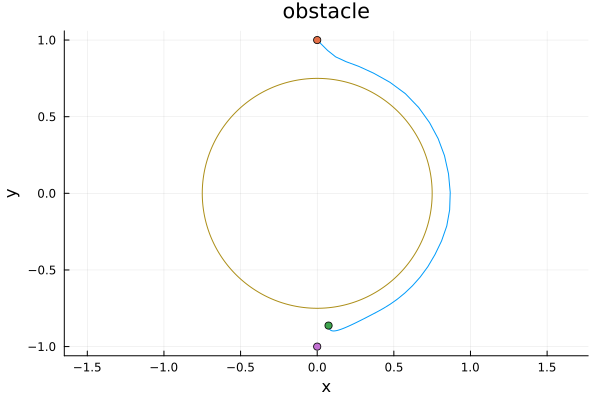

In [22]:
#this is the refined solution from ipopt 

plot(x_traj[1,:], x_traj[2,:], label="traj", title="Collision Avoidance Trajectory")

scatter!([x_traj[1,1]], [x_traj[2,1]], label="Start")

scatter!([x_traj[1,end]], [x_traj[2,end]], label="End")

scatter!([x_goal[1]], [x_goal[2]])

#scatter!([o_x], [o_y], label="obstacle")




##############################################
# Circle parameters
r = obstacle_r                # radius
cx, cy = o_x, o_y       # center

# Parametrize the circle
θ = range(0, 2π, length=500)
x_circle = cx .+ r .* cos.(θ)
y_circle = cy .+ r .* sin.(θ)

# Plot the circle
plot!(x_circle, y_circle, aspect_ratio=1, legend=false, xlabel="x", ylabel="y", title="obstacle")

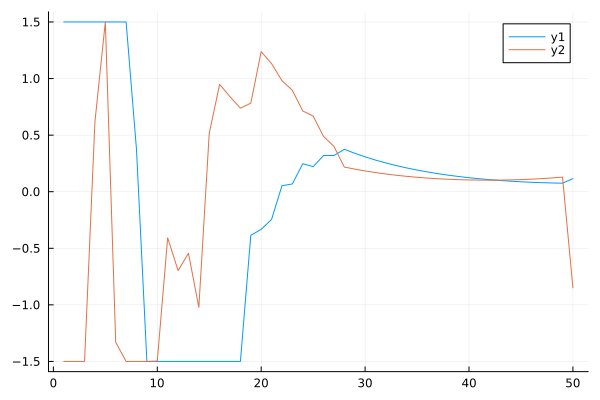

In [25]:
plot(u_traj') 

In [23]:
#order 2 causes problems -> maybe need to add bounds and redundant constraints. 

#ex. bounding states? 

In [24]:
#check out the moment matrix 

data.moment 

200-element Vector{Union{Float64, Symmetric{Float64, S} where S<:(AbstractMatrix{<:Float64}), Matrix{Float64}}}:
 [0.9999999923710776 -0.8693453889134045 … -0.8644954348785033 -0.9648310503607064; -0.8693453889134045 0.7559323204635169 … 0.751714499886596 0.8390766882238034; … ; -0.8644954348785033 0.751714499886596 … 0.7475202173465991 0.8343941099122086; -0.9648310503607064 0.8390766882238034 … 0.8343941099122086 0.9315359388582685]
 [0.9999999923710776 -0.0 … -0.0 -0.0; -0.0 0.0025223857586566664 … 0.0025009864984709166 0.0042607679291034725; … ; -0.0 0.0025009864984709166 … 0.0024797706552519166 0.004224234646277655; -0.0 0.0042607679291034725 … 0.004224234646277655 0.007276211238310433]
 [0.9999999923710776 0.08411101730388228 … 0.09674109286646856 0.12630075562562096; 0.08411101730388228 0.007088587848451712 … 0.00814526827333771 0.010566804276144103; … ; 0.09674109286646856 0.00814526827333771 … 0.009365221351202255 0.012199530757132475; 0.12630075562562096 0.010566804276144103 